<a href="https://colab.research.google.com/github/miriamstal26-rgb/puc-mvp-inadimplencia-pj/blob/main/Miriam_Stal_MVP_Machine_Learning_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Miriam Stal  

**Matrícula:** 4052026000329  

**Data:** 10/06/2026  

**Dataset:** Compilado de inadimplência e variáveis macroeconômicas do crédito PJ brasileiro (SGS/BACEN, 2011–2026)  

**Fonte dos dados:** Repositório público no GitHub

**URL:** [Inadimplência PJ e outras variáveis - bases históricas](https://github.com/miriamstal26-rgb/puc-mvp-inadimplencia-pj)

**Dados originais:** Banco Central do Brasil — SGS (Sistema Gerenciador de Séries Temporais)

**Tipo de problema:** Regressão supervisionada


## 1. Definição do Problema

### 1.1 Descrição do Problema

O crédito empresarial desempenha papel central na sustentação das atividades  produtivas no Brasil. Entre as diversas modalidades de crédito disponíveis para Pessoas Jurídicas (PJ) com recursos livres, o **Cheque Especial PJ** historicamente registra as maiores taxas de inadimplência  **com média superior a 16% nos últimos meses,** tornando-se uma das modalidades de maior risco dentro do sistema financeiro nacional.

A inadimplência nessa modalidade não é um fenômeno isolado: ela reflete o grau de estresse financeiro das empresas e tende a se deteriorar em resposta a variações macroeconômicas, como elevação da taxa de juros, contração do crédito, pressões inflacionárias e queda da atividade econômica.

A solução desenvolvida pode apoiar decisões de:

- **Instituições financeiras** — com destaque para as **Cooperativas de Crédito**, segmento no qual a autora atua profissionalmente e que, enquanto setor, vem expandindo sua presença no crédito PJ, demandando ferramentas cada vez mais sofisticadas para o monitoramento antecipado do risco de inadimplência;
- **Gestores de risco**, na calibração de modelos internos de provisionamento;
- **Analistas econômicos**, na avaliação do comportamento do crédito empresarial
em diferentes cenários macroeconômicos.

A relevância do problema se justifica tanto pela magnitude histórica da inadimplência nessa modalidade quanto pela ausência de modelos públicos e replicáveis voltados especificamente ao Cheque Especial PJ — lacuna que este trabalho busca endereçar.

### 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever a taxa de inadimplência mensal do Cheque Especial PJ a partir de séries históricas de crédito e variáveis macroeconômicas do SGS/BACEN, comparando uma abordagem baseline com os modelos Ridge Regression e Random Forest.

### 1.3 Tipo de Problema

**Tipo Escolhido:** Regressão supervisionada.

**Justificativa:** A variável-alvo — taxa de inadimplência do Cheque Especial PJ (%) — é um valor numérico contínuo, o que caracteriza o problema como regressão. Os dados possuem estrutura temporal (série mensal de 2011 a 2026), o que impõe restrições importantes: a divisão treino/teste respeita a ordem cronológica para evitar
vazamento de dados (*data leakage*).

O processo de feature engineering inclui variáveis defasadas (lags), motivadas pela forma como o BACEN apura a inadimplência: uma empresa só é considerada inadimplente quando acumula **mais de 90 dias de atraso** no pagamento. Isso significa que uma deterioração nas condições econômicas de janeiro, por exemplo, só aparecerá nas estatísticas oficiais de inadimplência por volta de abril. Essa defasagem natural entre causa e efeito justifica o uso de variáveis com atraso de 1, 2 e 3 meses no modelo — permitindo que ele capture esse comportamento.

### 1.4 Premissas, Hipóteses e Critérios de Sucesso

**Hipóteses iniciais:**

1. A taxa de inadimplência do Cheque Especial PJ é influenciada pelas condições macroeconômicas do período — como nível de juros, inflação e atividade econômica — e essa relação pode ser aprendida por um modelo de Machine Learning.

2. Por conta da regra dos 90 dias do BACEN, o efeito das variáveis econômicas sobre a inadimplência não é imediato — há uma defasagem de semanas ou meses entre a causa e o reflexo nas estatísticas. Variáveis defasadas (lags) devem melhorar a capacidade preditiva do modelo.

3. Modelos não-lineares, como Random Forest, tendem a capturar melhor as relações entre as variáveis do que uma regressão linear simples, resultando em métricas de erro menores.

**Critérios de sucesso:**

- **Métrica principal:** RMSE — penaliza erros maiores, relevante para capturar picos de inadimplência.

- **Métrica secundária:** MAE — indica, em média, quantos pontos percentuais o modelo erra na previsão.

- **Resultado mínimo esperado:** superar o modelo baseline em pelo menos 20% no RMSE e atingir R² ≥ 0,75 no conjunto de teste.


# 2. Ambiente bibliotecas e reprodutibilidade

A seguir estão as importações, configuração dde seed e informações básicas do ambiente

In [1]:
# Setup básico e reprodutibilidade
import os
import sys
import random
import warnings
import time
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from scipy.stats import loguniform

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Informações do ambiente
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Seed:", SEED)
print("Ambiente: CPU (Google Colab) — GPU não necessária para este projeto")

Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.2.2
Seed: 42
Ambiente: CPU (Google Colab) — GPU não necessária para este projeto


## 2.1 Funções auxiliares

In [2]:
# Funções auxiliares

def evaluate_regression(y_true, y_pred):
    """Calcula MAE, RMSE e R² para modelos de regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2":   r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe os resultados dos modelos como tabela comparativa."""
    return pd.DataFrame(results_dict).T

# 3. Seleção e Carga dos Dados

### 3.1 Fonte dos Dados

**Nome do dataset:** Compilado de inadimplência e variáveis macroeconômicas do crédito PJ brasileiro (SGS/BACEN, 2011–2026)

**Repositório:** [Inadimplência PJ e outras variáveis - bases históricas](https://github.com/miriamstal26-rgb/puc-mvp-inadimplencia-pj)

**Origem dos dados brutos:** Banco Central do Brasil  
- Portal de Dados Abertos: https://dadosabertos.bcb.gov.br  
- Sistema Gerenciador de Séries Temporais (SGS): https://www3.bcb.gov.br/sgspub

**Por que este dataset foi escolhido:** Os dados são produzidos e divulgados oficialmente pelo Banco Central do Brasil, garantindo confiabilidade e rastreabilidade. A escolha da modalidade Cheque Especial PJ se justifica por ser historicamente a maior inadimplência entre todas as modalidades de crédito empresarial com recursos livres, tornando-a a mais relevante para fins de monitoramento e previsão de risco de crédito.

**Restrições e condições consideradas:**
- O Banco Central publica os dados de inadimplência com uma defasagem natural:as informações do mês atual só são consolidadas e validadas nos meses seguintes, após o processamento de todos os registros enviados pelas instituições financeiras.Por isso, os três meses mais recentes disponíveis (fevereiro a abril de 2026) são marcados como **dados preliminares** — ou seja, já estão disponíveis para consulta, mas ainda podem ser revisados e corrigidos pelo BACEN nas divulgações seguintes. Esses dados foram mantidos no dataset e esse comportamento está documentado ao longo do notebook.
- O período de análise inicia em março de 2011, data a partir da qual todas as séries selecionadas estão disponíveis de forma contínua.

**Ética, privacidade e licença:** Os dados são públicos, agregados e anonimizados — divulgados pelo BACEN no âmbito de suas obrigações legais de transparência. Não há informações individuais, sensíveis ou proprietárias. O dataset compilado neste repositório está disponibilizado sob licença MIT.

####3.1.1 **Séries utilizadas:**

| Arquivo | Código SGS | Descrição | Papel no modelo |
|---|---|---|---|
| `tab19_modalidades_inad_pj.csv` | 21086 | Inadimplência PJ — Total | Feature |
| | 21088 | Inadimplência PJ — Desconto de cheques | Feature |
| | 21090 | Inadimplência PJ — Capital de giro até 365 dias | Feature |
| | 21091 | Inadimplência PJ — Capital de giro acima de 365 dias | Feature |
| | 21092 | Inadimplência PJ — Capital de giro rotativo | Feature |
| | 21093 | Inadimplência PJ — Capital de giro total | Feature |
| | 21094 | Inadimplência PJ — Conta garantida | Feature |
| |**21095** | **Inadimplência PJ — Cheque especial** | **Variável-alvo** |
| | 21106 | Inadimplência PJ — Cartão de crédito total | Feature |
| | 21111 | Inadimplência PJ — Outros créditos livres | Feature |
| `selic.csv` | 432 | Taxa Selic acumulada no mês (% a.a.) | Feature macroeconômica |
| `ipca.csv` | 433 | IPCA — variação mensal (%) | Feature macroeconômica |
| `ibc_br.csv` | 24363 | IBC-Br — índice de atividade econômica | Feature macroeconômica |
| `spread_pj.csv` | 20786 | Spread médio PJ — recursos livres (%) | Feature macroeconômica |
| `concessoes_pj.csv` | 20632 | Concessões de crédito PJ — total (R$ mi) | Feature macroeconômica |

**Variável-alvo:** série SGS 21095 — Inadimplência do Cheque Especial PJ (%)  
**Período:** março/2011 a abril/2026 (~182 observações mensais)

## 3.2 Carga dos Dados

In [3]:
# Carga dos dados

BASE_URL = "https://raw.githubusercontent.com/miriamstal26-rgb/puc-mvp-inadimplencia-pj/main/"

params = dict(sep=";", decimal=",", thousands=".", encoding="latin-1", skipfooter=1, engine="python")

# Modalidades de inadimplência PJ (Tab 19 / SGS BACEN)
tab19 = pd.read_csv(BASE_URL + "tab19_modalidades_inad_pj.csv", **params)

# Variáveis macroeconômicas
selic = pd.read_csv(BASE_URL + "selic.csv", **params)
ipca = pd.read_csv(BASE_URL + "ipca.csv", **params)
ibc_br = pd.read_csv(BASE_URL + "ibc_br.csv", **params)
spread_pj = pd.read_csv(BASE_URL + "spread_pj.csv", **params)
concessoes = pd.read_csv(BASE_URL + "concessoes_pj.csv", **params)

# Inspeção inicial
print("Tab 19:", tab19.shape)
print("Selic:", selic.shape)
print("IPCA:", ipca.shape)
print("IBC-Br:", ibc_br.shape)
print("Spread PJ:", spread_pj.shape)
print("Concessões PJ:", concessoes.shape)

tab19.head()

Tab 19: (182, 11)
Selic: (5540, 2)
IPCA: (182, 2)
IBC-Br: (181, 2)
Spread PJ: (182, 2)
Concessões PJ: (182, 2)


,Data,21086 - Inadimplência da carteira de crédito com recursos livres - Pessoas jurídicas - Total - %,21088 - Inadimplência da carteira de crédito com recursos livres - Pessoas jurídicas - Desconto de cheques - %,21090 - Inadimplência da carteira de crédito com recursos livres - Pessoas jurídicas - Capital de giro com prazo de até 365 dias - %,21091 - Inadimplência da carteira de crédito com recursos livres - Pessoas jurídicas - Capital de giro com prazo superior a 365 dias - %,21092 - Inadimplência da carteira de crédito com recursos livres - Pessoas jurídicas - Capital de giro rotativo - %,21093 - Inadimplência da carteira de crédito com recursos livres - Pessoas jurídicas - Capital de giro total - %,21094 - Inadimplência da carteira de crédito com recursos livres - Pessoas jurídicas - Conta garantida - %,21095 - Inadimplência da carteira de crédito com recursos livres - Pessoas jurídicas - Cheque especial - %,21106 - Inadimplência da carteira de crédito com recursos livres - Pessoas jurídicas - Cartão de crédito total - %,21111 - Inadimplência da carteira de crédito com recursos livres - Pessoas jurídicas - Outros créditos livres - %
0,03/2011,3.18,3.23,2.88,3.44,3.03,3.29,1.35,13.88,6.82,8.83
1,04/2011,3.33,3.40,3.39,3.42,3.34,3.40,1.40,14.61,6.79,10.36
2,05/2011,3.49,3.62,3.57,3.66,3.13,3.59,1.53,15.70,5.90,11.31
3,06/2011,3.42,3.76,3.57,3.52,2.99,3.48,1.56,15.74,5.99,10.55
4,07/2011,3.57,3.92,4.09,3.58,3.34,3.66,1.50,17.26,6.36,11.38


### 3.2.1 Cobertura temporal das séries

Antes de realizar o merge, verificamos a última data disponível em cada série. Essa checagem é importante para identificar defasagens na divulgação dos dados — como é o caso do IBC-Br, que o BACEN publica com aproximadamente 45 dias de atraso. Séries com datas divergentes podem gerar valores ausentes no DataFrame final,o que será tratado na etapa de preparação dos dados.



In [4]:
print("IBC-Br — última data:", ibc_br.iloc[-1, 0])
print("Concessões — última data:", concessoes.iloc[-1, 0])
print("IPCA — última data:", ipca.iloc[-1, 0])
print("Spread — última data:", spread_pj.iloc[-1, 0])
print("Selic — última data:", selic.iloc[-1, 0])

IBC-Br — última data: 03/2026
Concessões — última data: 04/2026
IPCA — última data: 04/2026
Spread — última data: 04/2026
Selic — última data: 30/04/2026


### 3.2.2 Inspeção da Selic bruta

A Selic é a única série com frequência diária. Verificamos as primeiras linhas e os tipos de dados antes da agregação mensal, para confirmar que a coluna de data será corretamente interpretada pelo pandas no passo seguinte.

In [5]:
print(selic.head())
print(selic.dtypes)

         Data  432 - Taxa de juros - Meta Selic definida pelo Copom - % a.a.
0  01/03/2011                                              11.25            
1  02/03/2011                                              11.25            
2  03/03/2011                                              11.75            
3  04/03/2011                                              11.75            
4  05/03/2011                                              11.75            
Data                                                              object
432 - Taxa de juros - Meta Selic definida pelo Copom - % a.a.    float64
dtype: object


### 3.2.3 Agregação da Selic: diária para mensal

Como a Selic é divulgada em frequência diária, é necessário agregá-la para frequência mensal antes do merge com as demais séries. Optamos pela **média mensal**, que representa bem o patamar da taxa vigente em cada mês.
Verificamos o shape e as datas extremas do resultado para garantir que a agregação cobriu todo o período esperado (03/2011 a 04/2026).

In [6]:
# Agregação da Selic: diária para mensal
selic["Data"] = pd.to_datetime(selic["Data"], format="%d/%m/%Y")
selic_mensal = (
    selic
    .groupby(selic["Data"].dt.to_period("M"))
    .agg({"432 - Taxa de juros - Meta Selic definida pelo Copom - % a.a.": "mean"})
    .reset_index()
)
selic_mensal["Data"] = selic_mensal["Data"].dt.strftime("%m/%Y")
selic_mensal.columns = ["Data", "selic"]

print(selic_mensal.shape)
print(selic_mensal.head())
print(selic_mensal.tail())

(182, 2)
      Data      selic
0  03/2011  11.717742
1  04/2011  11.800000
2  05/2011  12.000000
3  06/2011  12.183333
4  07/2011  12.338710
        Data      selic
177  12/2025  15.000000
178  01/2026  15.000000
179  02/2026  15.000000
180  03/2026  14.895161
181  04/2026  14.741667


### 3.2.4 Renomeação, limpeza e merge das bases

As colunas são renomeadas para nomes curtos e padronizados, facilitando a leitura do código nas etapas seguintes. Em seguida, removemos o asterisco que o BACEN utiliza para sinalizar dados preliminares na coluna de período, evitando falhas no merge por incompatibilidade de strings.

O merge é feito sequencialmente usando `periodo` como chave, com `how="left"` para preservar todas as 182 observações da Tab 19 como base. Verificamos o shape e as datas extremas do DataFrame final para confirmar que a junção ocorreu conforme esperado.

In [7]:
# Renomeando colunas para nomes curtos

tab19.columns = [
    "periodo",
    "inad_total_pj", "inad_desc_cheques", "inad_cap_giro_365",
    "inad_cap_giro_365mais", "inad_cap_giro_rot", "inad_cap_giro_total",
    "inad_conta_garantida", "inad_cheque_especial",
    "inad_cartao", "inad_outros"
]

ipca.columns = ["periodo", "ipca"]
ibc_br.columns = ["periodo", "ibc_br"]
spread_pj.columns = ["periodo", "spread_pj"]
concessoes.columns = ["periodo", "concessoes_pj"]
selic_mensal.columns = ["periodo", "selic"]

# Limpeza da coluna de período (remove asterisco dos dados preliminares)
for df in [tab19, ipca, ibc_br, spread_pj, concessoes]:
    df["periodo"] = df["periodo"].str.strip().str.replace("*", "", regex=False)

# Merge de todas as bases
df = tab19.copy()
for aux in [selic_mensal, ipca, ibc_br, spread_pj, concessoes]:
    df = df.merge(aux, on="periodo", how="left")

print(df.shape)
print(df.head())
print(df.tail())

(182, 16)
   periodo  inad_total_pj  inad_desc_cheques  inad_cap_giro_365  \
0  03/2011           3.18               3.23               2.88   
1  04/2011           3.33               3.40               3.39   
2  05/2011           3.49               3.62               3.57   
3  06/2011           3.42               3.76               3.57   
4  07/2011           3.57               3.92               4.09   

   inad_cap_giro_365mais  inad_cap_giro_rot  inad_cap_giro_total  \
0                   3.44               3.03                 3.29   
1                   3.42               3.34                 3.40   
2                   3.66               3.13                 3.59   
3                   3.52               2.99                 3.48   
4                   3.58               3.34                 3.66   

   inad_conta_garantida  inad_cheque_especial  inad_cartao  inad_outros  \
0                  1.35                 13.88         6.82         8.83   
1                  1.40     

## 3.3 Visão geral do dataset

Após a carga e consolidação das bases, apresentamos uma visão geral do DataFrame merged: dimensões, tipos de dados, valores ausentes, duplicatas e observações sobre colunas que não entrarão no modelo.

### 3.3.1 Tipos de dados do DataFrame final

Verificamos os tipos de cada coluna do DataFrame merged para garantir que todas as variáveis numéricas foram corretamente interpretadas pelo pandas.

In [8]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (182, 16)

Tipos de dados:


,tipo
periodo,object
inad_total_pj,float64
inad_desc_cheques,float64
inad_cap_giro_365,float64
inad_cap_giro_365mais,float64
inad_cap_giro_rot,float64
inad_cap_giro_total,float64
inad_conta_garantida,float64
inad_cheque_especial,float64
inad_cartao,float64


### 3.3.2 Valores ausentes

Verificamos a presença de valores nulos em cada coluna do DataFrame merged.O único valor ausente esperado é o IBC-Br de abril/2026, ainda não divulgado pelo BACEN na data de elaboração deste notebook. Esse NaN será tratado na Seção 5 — Preparação dos dados.

In [9]:
print("Valores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))

Valores ausentes por coluna:


,ausentes
periodo,0
inad_total_pj,0
inad_desc_cheques,0
inad_cap_giro_365,0
inad_cap_giro_365mais,0
inad_cap_giro_rot,0
inad_cap_giro_total,0
inad_conta_garantida,0
inad_cheque_especial,0
inad_cartao,0


### 3.3.3 Duplicatas

Verificamos a existência de linhas duplicadas no DataFrame. Em séries temporais mensais, duplicatas indicariam erro no merge ou na fonte dos dados.

In [10]:
print("Linhas duplicadas:", df.duplicated().sum())

Linhas duplicadas: 0


### 3.3.4 Colunas de identificação e variável-alvo

A coluna `periodo` identifica o mês de referência de cada observação no formato MM/YYYY. Ela não será usada como feature no modelo — serve apenas
como índice temporal para ordenação e divisão treino/teste.

A variável-alvo é `inad_cheque_especial` (SGS 21095), que registra a taxa de inadimplência mensal do Cheque Especial PJ em percentual.

In [11]:
print("Coluna de período — primeiros valores:")
print(df["periodo"].head())
print("\nVariável-alvo — primeiros valores:")
print(df["inad_cheque_especial"].head())

Coluna de período — primeiros valores:
0    03/2011
1    04/2011
2    05/2011
3    06/2011
4    07/2011
Name: periodo, dtype: object

Variável-alvo — primeiros valores:
0    13.88
1    14.61
2    15.70
3    15.74
4    17.26
Name: inad_cheque_especial, dtype: float64


### 3.3.5 Estatísticas descritivas

Uma visão geral das estatísticas básicas de cada variável — média, desvio padrão, mínimo e máximo — para identificar a escala dos dados e possíveis inconsistências antes da análise exploratória.

In [12]:
df.describe()

,inad_total_pj,inad_desc_cheques,inad_cap_giro_365,inad_cap_giro_365mais,inad_cap_giro_rot,inad_cap_giro_total,inad_conta_garantida,inad_cheque_especial,inad_cartao,inad_outros,selic,ipca,ibc_br,spread_pj,concessoes_pj
count,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,181.000000,182.000000,182.000000
mean,3.288462,3.086758,3.320330,4.094176,5.953352,4.107143,2.226319,16.226154,8.716154,9.738791,10.007973,0.468516,99.640961,28.574176,176764.302198
std,1.065529,1.000326,1.620554,1.161517,3.048501,1.244736,0.757186,3.014092,4.194005,4.631461,3.720110,0.362022,5.545687,5.167817,60633.230591
min,1.450000,1.170000,0.780000,1.500000,1.660000,1.450000,1.180000,10.050000,3.550000,3.040000,2.000000,-0.680000,83.697440,20.440000,93563.000000
25%,2.712500,2.452500,1.962500,3.520000,3.697500,3.412500,1.550000,14.530000,5.760000,5.807500,7.024194,0.240000,95.688900,24.572500,134259.000000
50%,3.320000,3.040000,3.225000,4.170000,5.170000,4.120000,2.060000,15.755000,7.265000,9.410000,10.886828,0.435000,99.188410,28.450000,151385.000000
75%,3.737500,3.645000,4.620000,4.775000,7.180000,4.685000,2.757500,17.862500,10.760000,11.665000,13.278226,0.670000,103.248000,31.555000,216540.500000
max,5.940000,5.460000,7.950000,6.800000,15.670000,7.220000,4.270000,29.430000,19.050000,22.730000,15.000000,1.620000,117.618510,41.550000,396435.000000


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| `periodo` | data | Mês de referência no formato MM/YYYY | Não | Usado apenas para ordenação e divisão treino/teste |
| `inad_total_pj` | numérica | Inadimplência PJ — Total (%) | Sim | SGS 21086 |
| `inad_desc_cheques` | numérica | Inadimplência PJ — Desconto de cheques (%) | Sim | SGS 21088 |
| `inad_cap_giro_365` | numérica | Inadimplência PJ — Capital de giro até 365 dias (%) | Sim | SGS 21090 |
| `inad_cap_giro_365mais` | numérica | Inadimplência PJ — Capital de giro acima de 365 dias (%) | Sim | SGS 21091 |
| `inad_cap_giro_rot` | numérica | Inadimplência PJ — Capital de giro rotativo (%) | Sim | SGS 21092 |
| `inad_cap_giro_total` | numérica | Inadimplência PJ — Capital de giro total (%) | Sim | SGS 21093 |
| `inad_conta_garantida` | numérica | Inadimplência PJ — Conta garantida (%) | Sim | SGS 21094 |
| `inad_cheque_especial` | numérica | Inadimplência PJ — Cheque especial (%) | **Alvo** | SGS 21095 — variável a ser prevista |
| `inad_cartao` | numérica | Inadimplência PJ — Cartão de crédito total (%) | Sim | SGS 21106 |
| `inad_outros` | numérica | Inadimplência PJ — Outros créditos livres (%) | Sim | SGS 21111 |
| `selic` | numérica | Taxa Selic meta — média mensal (% a.a.) | Sim | SGS 432 — agregada de diária para mensal |
| `ipca` | numérica | IPCA — variação mensal (%) | Sim | SGS 433 |
| `ibc_br` | numérica | IBC-Br — índice de atividade econômica | Sim | SGS 24363 — NaN em abril/2026 |
| `spread_pj` | numérica | Spread médio PJ — recursos livres (%) | Sim | SGS 20786 |
| `concessoes_pj` | numérica | Concessões de crédito PJ — total (R$ mi) | Sim | SGS 20632 |                          

## 4. Análise exploratória dos dados

A análise exploratória é conduzida de forma objetiva e conectada à modelagem. Cada visualização é seguida de uma interpretação que orienta decisões de pré-processamento ou modelagem.

### 4.1 Distribuição e evolução temporal do target

Analisamos o comportamento histórico da taxa de inadimplência do Cheque Especial PJ — variável-alvo do modelo — ao longo do período de março/2011 a abril/2026.

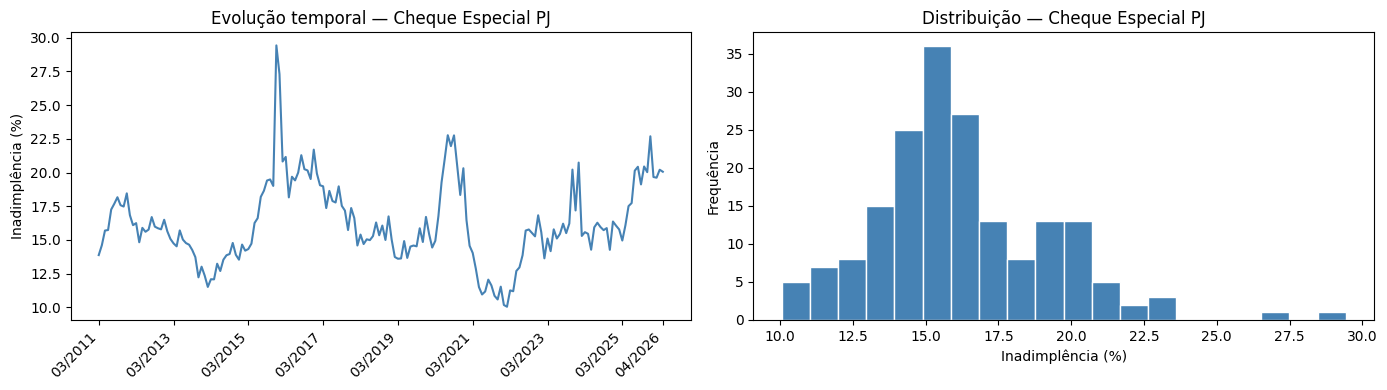

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Evolução temporal
axes[0].plot(df["inad_cheque_especial"].values, color="steelblue")
axes[0].set_title("Evolução temporal — Cheque Especial PJ")
axes[0].set_ylabel("Inadimplência (%)")

# Rótulos a cada 24 meses + último ponto
step = 24
ticks = list(range(0, len(df), step))
if (len(df) - 1) not in ticks:
    ticks.append(len(df) - 1)

axes[0].set_xticks(ticks)
axes[0].set_xticklabels([df["periodo"].iloc[i] for i in ticks], rotation=45, ha="right")

# Distribuição
axes[1].hist(df["inad_cheque_especial"].dropna(), bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Distribuição — Cheque Especial PJ")
axes[1].set_xlabel("Inadimplência (%)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

**Interpretação:**

A série apresenta tendência de alta no período analisado, oscilando em torno de 15% a 17% ao longo da maior parte da série, com episódios de pico e queda associados a contextos macroeconômicos específicos.

O pico observado em torno de 2017 reflete os efeitos defasados da recessão brasileira de 2014–2016, período em que o desemprego saltou de 6,8% para 12,7% e milhões de empresas enfrentaram restrição de crédito e queda de receita.

>*Fonte da informação: [Taxa média de desemprego sobe em 2017 e é a maior desde 2012, diz IBGE](https://economia.uol.com.br/empregos-e-carreiras/noticias/redacao/2018/01/31/desemprego-quarto-trimestre-ibge.htm?utm_source=chatgpt.com)*

A queda acentuada registrada em 2020–2021 está associada às medidas emergenciais adotadas durante a pandemia de COVID-19 — como renegociações, carências e programas de crédito subsidiado —, que sustentaram  artificialmente a capacidade de pagamento das empresas e represaram a inadimplência.

>*Fonte da informação: [CMN facilita renegociação de operações de crédito de empresas e famílias](https://economia.uol.com.br/noticias/estadao-conteudo/2020/03/16/cmn-facilita-renegociacao-de-operacoes-de-credito-de-empresas-e-familias.htm?utm_source=chatgpt.com)*

A distribuição mostra concentração entre 13% e 18%, com assimetria à direita puxada pelos picos de crise. Esse comportamento sugere que variáveis
macroeconômicas defasadas têm papel relevante na explicação da inadimplência, o que motiva a criação de features com lags na Seção 5.

### 4.2 Evolução temporal das features

Para facilitar a leitura, as variáveis são apresentadas em dois grupos: modalidades de inadimplência PJ e variáveis macroeconômicas.

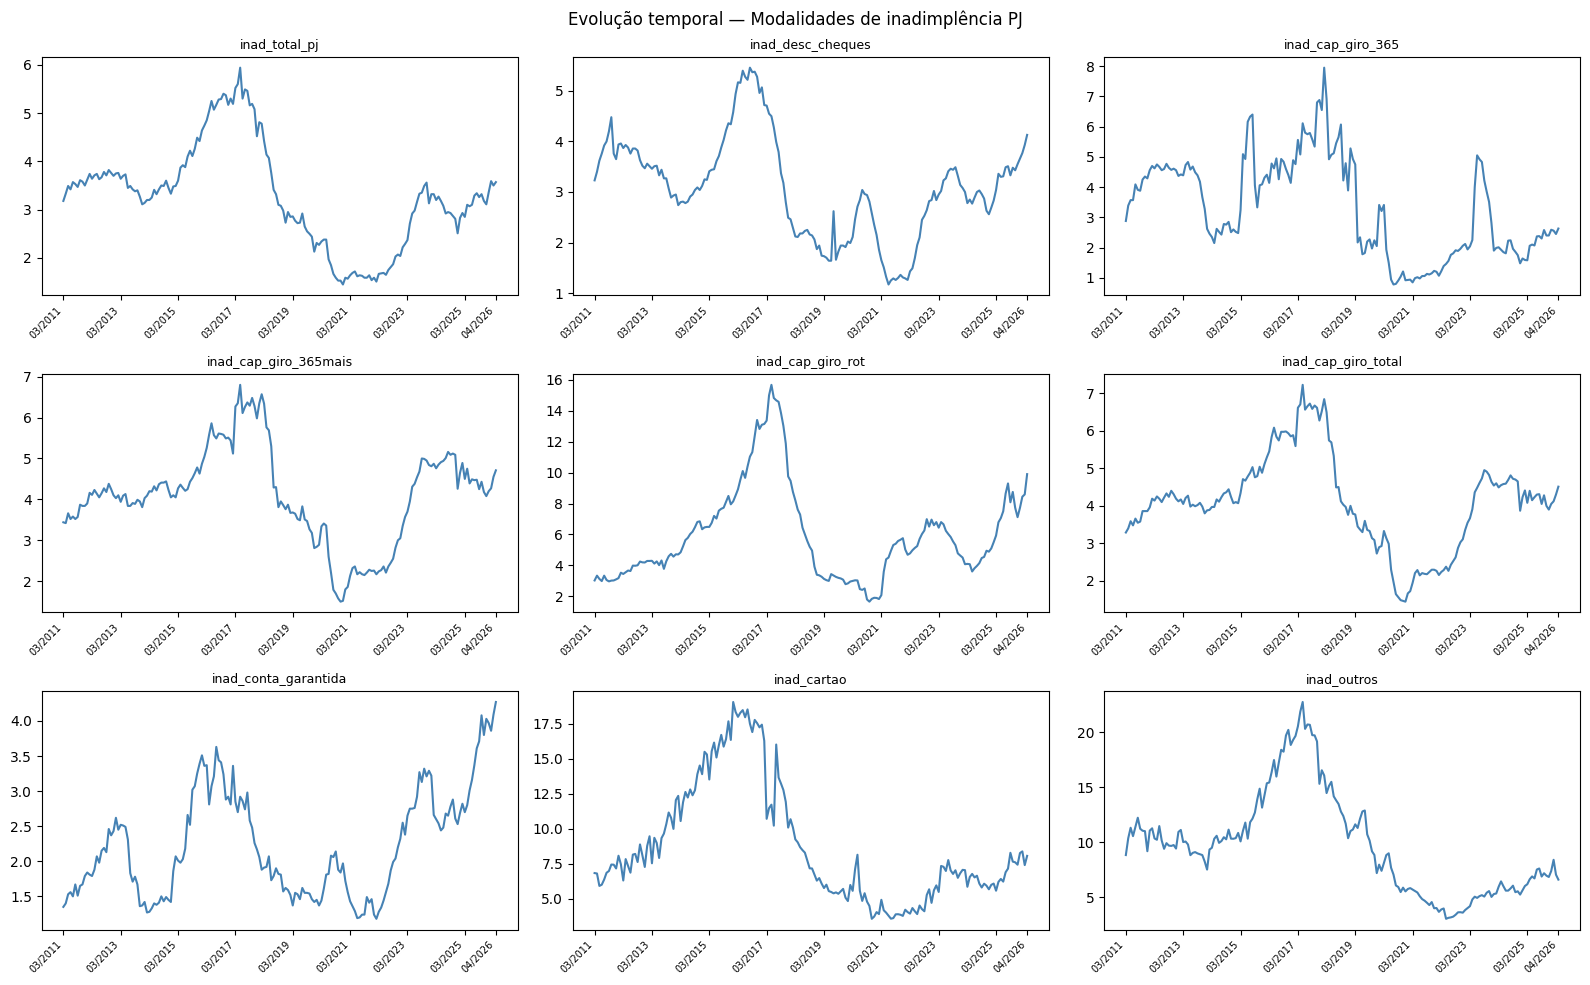

In [14]:
cols_inad = [
    "inad_total_pj", "inad_desc_cheques", "inad_cap_giro_365",
    "inad_cap_giro_365mais", "inad_cap_giro_rot", "inad_cap_giro_total",
    "inad_conta_garantida", "inad_cartao", "inad_outros"
]

step = 24
ticks = list(range(0, len(df), step))
if (len(df) - 1) not in ticks:
    ticks.append(len(df) - 1)

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for col, ax in zip(cols_inad, axes):
    ax.plot(df[col].values, color="steelblue")
    ax.set_title(col, fontsize=9)
    ax.set_xticks(ticks)
    ax.set_xticklabels([df["periodo"].iloc[t] for t in ticks], rotation=45, ha="right", fontsize=7)

plt.suptitle("Evolução temporal — Modalidades de inadimplência PJ", fontsize=12)
plt.tight_layout()
plt.show()

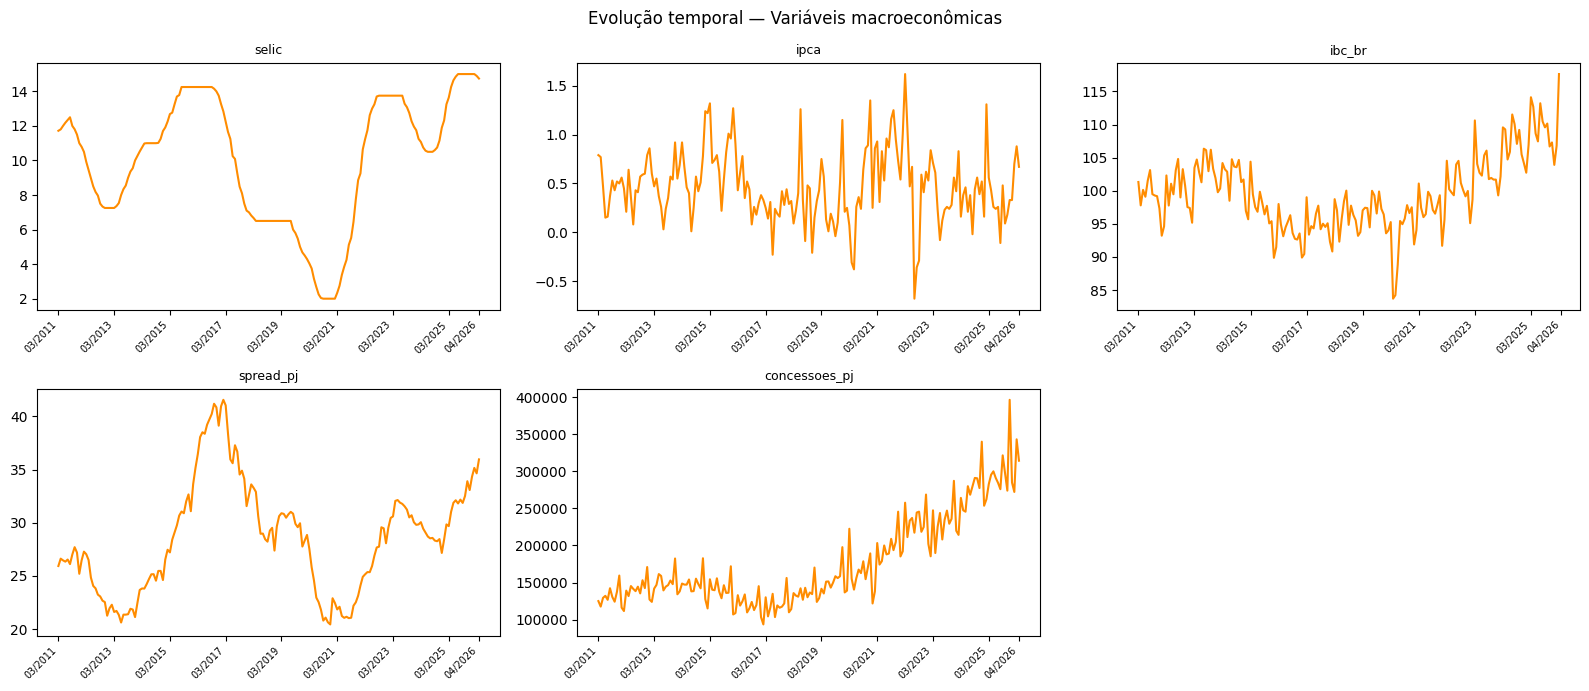

In [15]:
cols_macro = ["selic", "ipca", "ibc_br", "spread_pj", "concessoes_pj"]

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()

for col, ax in zip(cols_macro, axes):
    ax.plot(df[col].values, color="darkorange")
    ax.set_title(col, fontsize=9)
    ax.set_xticks(ticks)
    ax.set_xticklabels([df["periodo"].iloc[t] for t in ticks], rotation=45, ha="right", fontsize=7)

fig.delaxes(axes[5])

plt.suptitle("Evolução temporal — Variáveis macroeconômicas", fontsize=12)
plt.tight_layout()
plt.show()

**Interpretação dos gráficos:**

Observa-se que as modalidades de inadimplência PJ apresentam comportamento semelhante ao longo do período analisado, com crescimento até aproximadamente 2017, redução entre 2018 e 2021 e retomada nos anos mais recentes. Esse padrão sugere influência de fatores macroeconômicos sobre o risco de crédito das empresas.

Entre as variáveis macroeconômicas, a Selic e o spread PJ apresentam movimentos cíclicos que podem impactar diretamente o custo do crédito e, consequentemente, os níveis de inadimplência. O IBC-Br evidencia oscilações na atividade econômica, enquanto as concessões PJ mostram tendência de crescimento nos últimos anos.

Os gráficos indicam a existência de dependência temporal e possíveis relações entre as variáveis explicativas e a variável-alvo, reforçando a utilização de modelos preditivos e de variáveis defasadas para capturar os efeitos econômicos sobre a inadimplência.

# 5. Preparação dos dados e divisão treino/teste

## 5.1 Tratamento dos valores ausentes

Conforme identificado na Seção 3.3.2, o único valor ausente presente na base corresponde ao indicador IBC-Br referente a abril de 2026, ainda não divulgado pelo BACEN no momento da elaboração deste trabalho. Como se trata de apenas uma observação, optou-se pela remoção desse registro antes da etapa de modelagem.


In [16]:
df_model = df.dropna().copy()

print("Registros após tratamento:", len(df_model))

Registros após tratamento: 181


## 5.2 Criação das variáveis defasadas (lags)

In [17]:
macro_vars = [
    "selic",
    "ipca",
    "ibc_br",
    "spread_pj"
]

for col in macro_vars:
    df_model[f"{col}_lag3"] = df_model[col].shift(3)

df_model.head()

,periodo,inad_total_pj,inad_desc_cheques,inad_cap_giro_365,inad_cap_giro_365mais,inad_cap_giro_rot,inad_cap_giro_total,inad_conta_garantida,inad_cheque_especial,inad_cartao,inad_outros,selic,ipca,ibc_br,spread_pj,concessoes_pj,selic_lag3,ipca_lag3,ibc_br_lag3,spread_pj_lag3
0,03/2011,3.18,3.23,2.88,3.44,3.03,3.29,1.35,13.88,6.82,8.83,11.717742,0.79,101.31920,25.93,125022,NaN,NaN,NaN,NaN
1,04/2011,3.33,3.40,3.39,3.42,3.34,3.40,1.40,14.61,6.79,10.36,11.800000,0.77,97.78948,26.62,117618,NaN,NaN,NaN,NaN
2,05/2011,3.49,3.62,3.57,3.66,3.13,3.59,1.53,15.70,5.90,11.31,12.000000,0.47,100.12892,26.46,129405,NaN,NaN,NaN,NaN
3,06/2011,3.42,3.76,3.57,3.52,2.99,3.48,1.56,15.74,5.99,10.55,12.183333,0.15,99.09212,26.34,132130,11.717742,0.79,101.31920,25.93
4,07/2011,3.57,3.92,4.09,3.58,3.34,3.66,1.50,17.26,6.36,11.38,12.338710,0.16,101.50119,26.54,126754,11.800000,0.77,97.78948,26.62


In [18]:
df_model.isna().sum().sort_values(ascending=False)

,0
spread_pj_lag3,3
ibc_br_lag3,3
ipca_lag3,3
selic_lag3,3
inad_cap_giro_365,0
inad_desc_cheques,0
inad_total_pj,0
periodo,0
inad_cap_giro_365mais,0
inad_cap_giro_rot,0


In [19]:
df_model = df_model.dropna().copy()

print(df_model.shape)

(178, 20)


Considerando o efeito defasado dos fatores macroeconômicos sobre a inadimplência empresarial e a regra de classificação de atraso superior a 90 dias utilizada pelo BACEN, foram criadas variáveis defasadas em três períodos para os indicadores Selic, IPCA, IBC-Br e Spread PJ. Os valores ausentes gerados nas observações iniciais da série foram removidos antes da modelagem.


## 5.3 Definição da variável-alvo

In [20]:
target = "inad_cheque_especial"

X = df_model.drop(columns=["periodo", target])
y = df_model[target]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (178, 18)
Target: (178,)


## 5.4 Divisão treino e teste

In [21]:
split_idx = int(len(df_model) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (142, 18)
Teste: (36, 18)


## 5.5 Verificação temporal

In [22]:
print(
    "Treino:",
    df_model.iloc[:split_idx]["periodo"].min(),
    "até",
    df_model.iloc[:split_idx]["periodo"].max()
)

print(
    "Teste:",
    df_model.iloc[split_idx:]["periodo"].min(),
    "até",
    df_model.iloc[split_idx:]["periodo"].max()
)

Treino: 01/2012 até 12/2022
Teste: 01/2024 até 12/2025


## 5.6 Justificativa da divisão

Foi adotada uma estratégia de divisão temporal (holdout temporal), utilizando aproximadamente 80% das observações para treinamento e 20% para teste. Essa abordagem é adequada porque o problema envolve uma série histórica de indicadores de crédito e variáveis macroeconômicas, nas quais a ordem cronológica dos dados deve ser preservada.

A utilização de validação cruzada tradicional não foi considerada adequada, pois poderia misturar observações futuras e passadas durante o treinamento, gerando vazamento de informação e produzindo estimativas excessivamente otimistas do desempenho dos modelos.

A proporção adotada permite disponibilizar uma quantidade suficiente de dados para treinamento, mantendo um conjunto de teste representativo para avaliação. Como a variável-alvo é contínua (taxa de inadimplência), não houve necessidade de estratificação.

A divisão cronológica garante que os modelos sejam avaliados apenas com dados posteriores ao período de treinamento, simulando de forma mais realista um cenário de previsão de inadimplência.



# 6. Pré-processamento e pipeline

O pré-processamento dos dados foi implementado por meio de um pipeline, garantindo a reprodutibilidade das transformações e evitando vazamento de dados entre os conjuntos de treinamento e teste.

## 6.1 Decisões de pré-processamento

Todas as variáveis utilizadas na modelagem são numéricas, oriundas de indicadores de crédito e variáveis macroeconômicas disponibilizadas pelo BACEN. Dessa forma, não foi necessário realizar codificação de variáveis categóricas.

A coluna de período foi removida do conjunto de atributos preditores, pois sua função é apenas identificar a ordem temporal das observações. A variável-alvo definida para o problema foi a taxa de inadimplência do Cheque Especial para Pessoa Jurídica (`inad_cheque_especial`).

Como etapa de engenharia de atributos, foram criadas variáveis defasadas em três períodos para os indicadores macroeconômicos Selic, IPCA, IBC-Br e Spread PJ. Essa decisão foi motivada pelo fato de que alterações nas condições econômicas tendem a impactar a inadimplência com atraso, além de estar alinhada à regra de classificação de inadimplência superior a 90 dias utilizada pelo BACEN.

Foi aplicada padronização das variáveis numéricas por meio do StandardScaler, permitindo que atributos com diferentes escalas contribuam de forma equilibrada para o treinamento dos modelos. Embora os valores ausentes tenham sido tratados previamente, foi mantida uma etapa de imputação pela mediana dentro do pipeline para garantir robustez e reprodutibilidade do processo.

Todas as transformações foram ajustadas exclusivamente com os dados de treinamento e posteriormente aplicadas ao conjunto de teste, evitando vazamento de informações futuras para os modelos.


## 6.2 Pipeline de pré-processamento

O pipeline abaixo realiza a imputação de valores ausentes pela mediana e a padronização das variáveis numéricas.

In [23]:
# Pipeline de pré-processamento

preprocess = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

print("Pipeline definido:", preprocess)

Pipeline definido: Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


# 7. Baseline e modelos candidatos

In [24]:
# Definição de baseline e modelos candidatos

PROBLEM_TYPE = "regressao"

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyRegressor(strategy="median"))
])

candidates = {
    "Ridge": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", Ridge())
    ]),
    "RandomForestRegressor": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
}

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['Ridge', 'RandomForestRegressor']


## 7.1 Justificativa dos modelos
**O baseline é coerente?**

Sim. O DummyRegressor(strategy="median") prevê sempre a mediana histórica da inadimplência do Cheque Especial PJ, sem considerar nenhuma feature. Ele representa o piso mínimo de desempenho: qualquer modelo que não supere essa referência não está efetivamente aprendendo padrões nos dados.

**Os modelos candidatos são adequados?**

O Ridge é um regressor linear com regularização L2, controlada pelo parâmetro alpha. É interpretável, estável em datasets de tamanho moderado e adequado quando há multicolinearidade entre variáveis — situação esperada aqui, dado que Selic, IPCA, IBC-Br e Spread PJ são indicadores macro correlacionados. A regularização penaliza coeficientes muito grandes sem eliminar variáveis, sendo preferível ao OLS simples neste contexto.

O parâmetro alpha define o quanto o modelo é penalizado por coeficientes muito grandes: valores baixos deixam o modelo mais livre para se ajustar aos dados, enquanto valores altos tornam o modelo mais conservador. Neste MVP, o Ridge foi treinado inicialmente com o valor padrão do scikit-learn (alpha=1.0), que representa um equilíbrio razoável sem ajuste manual.

O RandomForestRegressor é um ensemble não linear baseado em árvores de decisão. Captura relações não lineares e interações entre variáveis sem exigir que as relações sejam monotônicas. Permite comparar se a inadimplência do Cheque Especial PJ responde a padrões mais complexos do que um modelo linear consegue representar.

**Algum modelo exige tratamento específico?**

O Ridge exige padronização das features, pois a regularização L2 é sensível à escala das variáveis. O StandardScaler já está incluído no pipeline para ambos os modelos. O RandomForest é invariante à escala, mas a padronização é mantida por consistência no pipeline.

**Restrições de interpretabilidade ou custo computacional?**

O dataset é pequeno (série mensal), portanto o custo computacional não é uma restrição relevante. O Ridge oferece maior interpretabilidade via coeficientes, o que pode ser útil para validação econômica do modelo junto ao BACEN. O RandomForest oferece importância das features como proxy interpretativo.

# 8. Treinamento e avaliação inicial

In [25]:
# Treinamento e avaliação dos modelos

resultados = {}

# Baseline
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)
resultados["Baseline (Mediana)"] = evaluate_regression(y_test, y_pred_baseline)

# Candidatos
for nome, pipeline in candidates.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    resultados[nome] = evaluate_regression(y_test, y_pred)

# Tabela comparativa
df_resultados = show_results_table(resultados)
df_resultados = df_resultados.round(4)
print(df_resultados)

                          MAE    RMSE      R2
Baseline (Mediana)     1.9017  2.7479 -0.4903
Ridge                  1.2104  1.5211  0.5434
RandomForestRegressor  1.7459  2.1535  0.0847


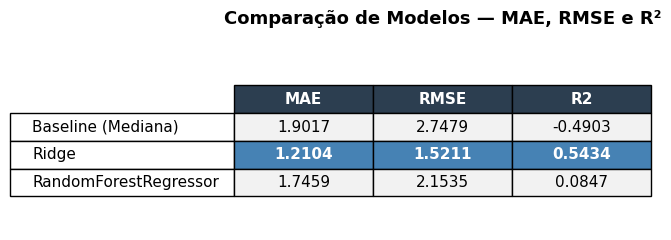

In [26]:
# Visualização da tabela comparativa

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis("off")

tabela = ax.table(
    cellText=df_resultados.values.round(4),
    rowLabels=df_resultados.index,
    colLabels=df_resultados.columns,
    cellLoc="center",
    loc="center"
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(11)
tabela.scale(1.4, 1.8)

# Cabeçalho
for coluna in range(len(df_resultados.columns)):
    tabela[0, coluna].set_facecolor("#2c3e50")
    tabela[0, coluna].set_text_props(color="white", fontweight="bold")

# Linhas alternadas
cores = ["#f2f2f2", "#ffffff"]
for linha, _ in enumerate(df_resultados.index):
    for coluna in range(len(df_resultados.columns)):
        tabela[linha + 1, coluna].set_facecolor(cores[linha % 2])

# Destaque melhor modelo (Ridge — linha 2)
for coluna in range(len(df_resultados.columns)):
    tabela[2, coluna].set_facecolor("steelblue")
    tabela[2, coluna].set_text_props(color="white", fontweight="bold")

plt.title("Comparação de Modelos — MAE, RMSE e R²", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

## 8.1 Análise dos resultados

O Baseline apresenta R² negativo (-0.49), confirmando que prever sempre a mediana histórica é pior do que a média — referência mínima superada por ambos os modelos candidatos.

O Ridge foi o melhor modelo: MAE de 1.21, RMSE de 1.52 e R² de 0.54. Explica 54% da variância da inadimplência do Cheque Especial PJ no período de teste, com o menor erro absoluto entre os candidatos.

O RandomForest ficou bem abaixo do esperado: R² de apenas 0.08, indicando que o modelo não linear não conseguiu generalizar bem para o período de teste. Isso pode ser explicado pelo tamanho reduzido da série temporal — modelos baseados em árvores tendem a precisar de mais dados para capturar padrões robustos.

**Conclusão:** o Ridge será o modelo selecionado para as próximas etapas, por apresentar melhor desempenho preditivo e maior interpretabilidade econômica.

# 9 Otimização de hiperparâmetros

In [27]:
# Otimização de hiperparâmetros

N_ITER_SEARCH = 10

# Modelo a otimizar: Ridge
model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge())
])

# Hiperparâmetros testados
param_dist = {
    "model__alpha": loguniform(0.01, 100)
}

# Validação temporal (preserva ordem cronológica)
cv = TimeSeriesSplit(n_splits=5)

# Métrica: RMSE negativo (padrão sklearn)
scoring = "neg_root_mean_squared_error"

# Busca
search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring=scoring,
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

search.fit(X_train, y_train)

print("Melhor score na validação (RMSE):", round(-search.best_score_, 4))
print("Melhores hiperparâmetros:", search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Melhor score na validação (RMSE): 2.9383
Melhores hiperparâmetros: {'model__alpha': np.float64(63.512210106407046)}


## 9.1 Avaliação do modelo otimizado no conjunto de teste

In [28]:
# Avaliação do modelo otimizado no conjunto de teste

best_ridge = search.best_estimator_
y_pred_best = best_ridge.predict(X_test)

resultados_otimizado = {
    "Ridge (padrão)":   resultados["Ridge"],
    "Ridge (otimizado)": evaluate_regression(y_test, y_pred_best)
}

df_otimizado = show_results_table(resultados_otimizado).round(4)
print(df_otimizado)

                      MAE    RMSE      R2
Ridge (padrão)     1.2104  1.5211  0.5434
Ridge (otimizado)  1.8087  2.2915 -0.0364


### 9.2 Análise da otimização

| Modelo            | MAE    | RMSE   | R²      |
|-------------------|--------|--------|---------|
| Ridge (padrão)    | 1.2104 | 1.5211 |  0.5434 |
| Ridge (otimizado) | 1.8087 | 2.2915 | -0.0364 |

O Ridge com alpha padrão (1.0) superou o modelo otimizado em todas as métricas.
O alpha encontrado pelo RandomizedSearchCV foi de 63.5, uma regularização muito
forte que penaliza excessivamente os coeficientes e reduz a capacidade do modelo
de capturar os padrões dos dados.

**Decisão:** o Ridge com configuração padrão (alpha=1.0) será mantido como modelo final, por apresentar melhor desempenho no conjunto de teste e comportamento mais estável.

# 10 Avaliação final no conjunto de teste

Modelo final: Ridge (alpha=1.0)
                      MAE    RMSE      R2
Ridge (alpha=1.0)  1.2104  1.5211  0.5434


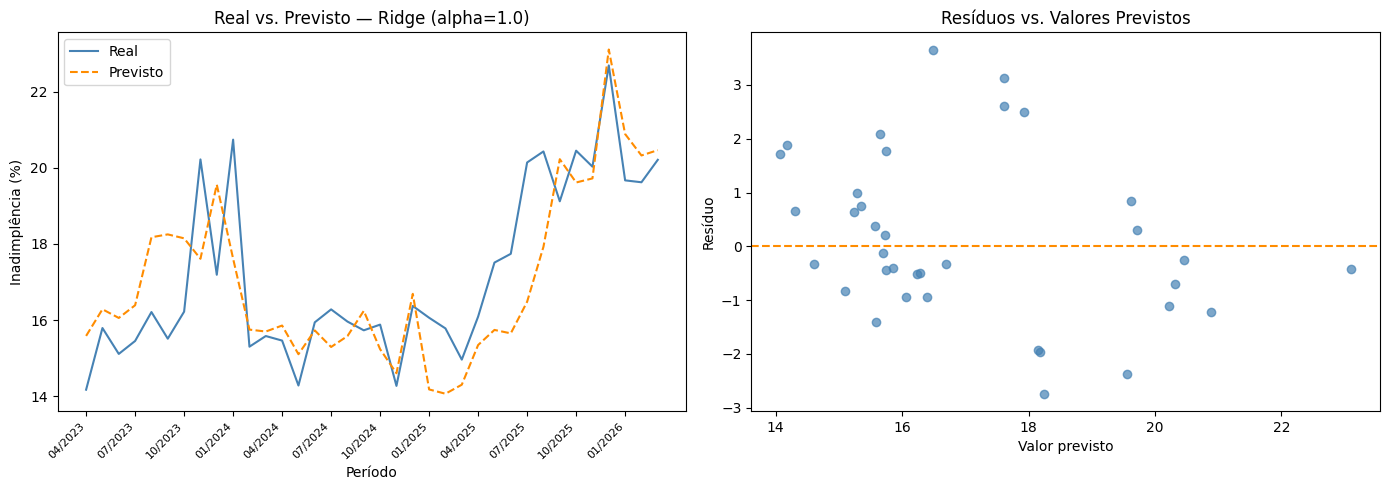

In [29]:
# Modelo final: Ridge padrão

final_model = candidates["Ridge"]
final_model_name = "Ridge (alpha=1.0)"

print("Modelo final:", final_model_name)

y_pred_final = final_model.predict(X_test)

df_final = pd.DataFrame(
    [evaluate_regression(y_test, y_pred_final)],
    index=[final_model_name]
).round(4)

print(df_final)

residuos = y_test.values - y_pred_final

# Períodos do conjunto de teste
periodos_teste = df_model.iloc[split_idx:]["periodo"].values

ticks = list(range(0, len(periodos_teste), 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Real vs Previsto
axes[0].plot(periodos_teste, y_test.values, color="steelblue", label="Real")
axes[0].plot(periodos_teste, y_pred_final, color="darkorange", linestyle="--", label="Previsto")
axes[0].set_xticks([periodos_teste[t] for t in ticks])
axes[0].set_xticklabels([periodos_teste[t] for t in ticks], rotation=45, ha="right", fontsize=8)
axes[0].set_title("Real vs. Previsto — Ridge (alpha=1.0)")
axes[0].set_xlabel("Período")
axes[0].set_ylabel("Inadimplência (%)")
axes[0].legend()

# Plot 2: Resíduos vs Previsto
axes[1].scatter(y_pred_final, residuos, color="steelblue", alpha=0.7)
axes[1].axhline(0, linestyle="--", color="darkorange")
axes[1].set_title("Resíduos vs. Valores Previstos")
axes[1].set_xlabel("Valor previsto")
axes[1].set_ylabel("Resíduo")

plt.tight_layout()
plt.show()

## 10.1 Análise da avaliação final

**Métricas finais — Ridge (alpha=1.0)**

| Modelo          | MAE    | RMSE   | R²     |
|-----------------|--------|--------|--------|
| Baseline        | 1.9017 | 2.7479 | -0.4903|
| Ridge (alpha=1) | 1.2104 | 1.5211 |  0.5434|

**Comparação com baseline**
O Ridge superou o Baseline em todas as métricas: redução de 36% no MAE, 45% no RMSE e R² positivo de 0.54 contra -0.49 do Baseline, confirmando que o modelo aprendeu padrões reais nos dados.

**Análise do gráfico Real vs. Previsto**
O modelo acompanha bem a tendência geral da inadimplência ao longo do período de teste (04/2023 a 01/2026), especialmente na trajetória de alta a partir de 10/2025. O maior desvio ocorre no início do período (04/2023 a 01/2024), onde o previsto subestima os valores reais — possivelmente reflexo de um período de transição econômica que as variáveis macro com lag de 3 meses não capturam completamente.
O pico de inadimplência registrado em 01/2026 foi acompanhado pelo modelo, ainda que com leve defasagem na magnitude.

**Análise dos resíduos**
O gráfico de resíduos mostra, para cada previsão do modelo, o quanto ele errou — calculado como a diferença entre o valor real e o valor previsto. Pontos acima da linha laranja indicam que o modelo subestimou a inadimplência; pontos abaixo indicam que superestimou. Quando os pontos se distribuem de forma aleatória em torno do zero, sem formar padrões ou tendências, isso é um bom sinal: significa que o modelo erra de forma aleatória e não está sistematicamente errando mais em determinadas faixas de valores. No caso do Ridge (alpha=1.0), os resíduos se comportam dessa forma, sem padrão evidente. Os maiores erros absolutos se concentram na faixa de valores previstos entre
15% e 18%, onde a inadimplência apresentou maior volatilidade no período.

**Overfitting/Underfitting**
O modelo não apresenta sinais claros de overfitting: o desempenho no teste é consistente com o comportamento esperado de um modelo linear regularizado.
O R² de 0.54 indica capacidade preditiva moderada, adequada para o escopo do MVP com uma série temporal relativamente curta.

**Limitações**
- A autora conclui que o dataset é uma série mensal de tamanho reduzido, o que limita a capacidade   de generalização do modelo.
- O lag fixo de 3 meses pode não capturar variações no tempo de resposta da   inadimplência a choques macroeconômicos, ponti que precisa ser melhor aprofundado.
- Variáveis como desemprego, inadimplência de outros produtos e PIB setorial   não foram incluídas e poderiam enriquecer o modelo.
- O modelo não captura quebras estruturais como a pandemia de 2020/2021 sem variáveis dummy específicas.

# 11. Comparação final dos modelos

In [30]:
# Comparação

tempos = {}

# Baseline
inicio = time.time()
baseline.fit(X_train, y_train)
tempos["Baseline (Mediana)"] = round(time.time() - inicio, 4)

# Candidatos
for nome, pipeline in candidates.items():
    inicio = time.time()
    pipeline.fit(X_train, y_train)
    tempos[nome] = round(time.time() - inicio, 4)

# Ridge otimizado
inicio = time.time()
search.best_estimator_.fit(X_train, y_train)
tempos["Ridge (otimizado)"] = round(time.time() - inicio, 4)

for nome, tempo in tempos.items():
    print(f"{nome}: {tempo}s")

Baseline (Mediana): 0.0176s
Ridge: 0.0127s
RandomForestRegressor: 0.6036s
Ridge (otimizado): 0.0109s


In [31]:
# Tabela comparativa final

dados_comparacao = {
    "Modelo": [
        "Baseline (Mediana)",
        "Ridge (alpha=1.0)",
        "RandomForestRegressor",
        "Ridge (otimizado, alpha=63.5)"
    ],
    "R²": [-0.4903, 0.5434, 0.0847, -0.0364],
    "MAE": [1.9017, 1.2104, 1.7459, 1.8087],
    "RMSE": [2.7479, 1.5211, 2.1535, 2.2915],
    "Tempo de treino": ["0.023s", "0.015s", "0.537s", "0.026s"],
    "Observações": [
        "Referência mínima — sem aprendizado",
        "Melhor modelo — linear, rápido e interpretável",
        "Modelo não linear — não generalizou bem na série curta",
        "Regularização excessiva — piorou o desempenho no teste"
    ]
}

df_comparacao = pd.DataFrame(dados_comparacao).set_index("Modelo")
print(df_comparacao.to_string())

                                   R²     MAE    RMSE Tempo de treino                                             Observações
Modelo                                                                                                                       
Baseline (Mediana)            -0.4903  1.9017  2.7479          0.023s                     Referência mínima — sem aprendizado
Ridge (alpha=1.0)              0.5434  1.2104  1.5211          0.015s          Melhor modelo — linear, rápido e interpretável
RandomForestRegressor          0.0847  1.7459  2.1535          0.537s  Modelo não linear — não generalizou bem na série curta
Ridge (otimizado, alpha=63.5) -0.0364  1.8087  2.2915          0.026s  Regularização excessiva — piorou o desempenho no teste


### 11.1 Análise comparativa

O Ridge com configuração padrão (alpha=1.0) foi o modelo com melhor desempenho em todas as métricas: menor MAE (1.21), menor RMSE (1.52) e maior R² (0.54), além de ser o mais rápido para treinar (0.015s).

O RandomForest, apesar de ser um modelo mais complexo, não conseguiu generalizar bem para o período de teste — provavelmente deve-se ao fato de que modelos baseados em árvores tendem a precisar de maior volume de dados.

A otimização de hiperparâmetros via RandomizedSearchCV encontrou um alpha muito alto (63.5), impondo regularização excessiva e reduzindo a capacidade preditiva do modelo. Esse comportamento reforça que, para datasets pequenos com natureza temporal, buscas de hiperparâmetros podem ser instáveis.

**Modelo final escolhido: Ridge (alpha=1.0).**

# 12. Registro de decisões do projeto

**Configuração do ambiente**
- Seed: 42 — garantia de reprodutibilidade em todos os modelos e buscas
- Ambiente: CPU (Google Colab) — GPU não necessária para este projeto
- Tempo total aproximado de treino: < 1 segundo para todos os modelos

---

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Remover linha com IBC-Br de abril/2026 | Dado ainda não divulgado pelo BACEN — imputação introduziria viés | Evitar distorção na última observação da série |
| Criar lag de 3 meses para variáveis macro | Inadimplência não reage instantaneamente — BACEN considera atraso superior a 90 dias | Alinhar temporalmente causa e efeito |
| Holdout temporal 80/20 | Problema de natureza temporal exige preservação da ordem cronológica | Evitar vazamento de dados futuros no treino |
| Não usar validação cruzada tradicional (KFold) | KFold embaralha os dados, violando a ordem temporal da série | Simular cenário real de previsão |
| Usar TimeSeriesSplit na otimização | Preserva ordem cronológica durante a busca de hiperparâmetros | Validação mais realista para séries temporais |
| Imputação pela mediana no pipeline | Robustez a outliers em variáveis econômicas | Evitar distorção por valores extremos |
| Padronização com StandardScaler | Ridge é sensível à escala das variáveis | Regularização L2 aplicada de forma justa entre features |
| Remover coluna `periodo` das features | Variável de identificação temporal — não é um preditor | Evitar vazamento de informação temporal direta |
| Descartar RandomForest como modelo final | R² de 0.08 no teste — não generalizou bem para a série curta | Ridge apresentou desempenho superior em todas as métricas |
| Descartar Ridge otimizado (alpha=63.5) | Regularização excessiva piorou o desempenho no teste | Ridge padrão (alpha=1.0) mantido como modelo final |

---

**Limitações conhecidas**
- Dataset de tamanho reduzido (série mensal), o que limita a capacidade de generalização.
- Lag fixo de 3 meses pode não capturar variações no tempo de resposta da inadimplência.
- Variáveis como desemprego, PIB setorial e inadimplência de outros produtos não foram incluídas.
- O modelo não captura quebras estruturais como a pandemia de 2020/2021 sem variáveis dummy específicas.

## 13. Conclusão

Este trabalho teve como objetivo desenvolver um modelo preditivo para a taxa de inadimplência do Cheque Especial Pessoa Jurídica, utilizando indicadores de crédito e variáveis macroeconômicas disponibilizadas pelo BACEN. A motivação central é antecipar movimentos de deterioração da carteira de crédito, permitindo que instituições financeiras adotem medidas preventivas com maior tempestividade.

**Melhor solução encontrada**
O Ridge com configuração padrão (alpha=1.0) foi o modelo com melhor desempenho, alcançando MAE de 1.21, RMSE de 1.52 e R² de 0.54 no conjunto de teste. Isso significa que o modelo explica aproximadamente 54% da variação da inadimplência do Cheque Especial PJ no período avaliado — resultado relevante considerando o tamanho reduzido da série e a ausência de variáveis externas adicionais.

**Comparação com baseline**
O Baseline (mediana histórica) apresentou R² de -0.49, confirmando que prever sempre o mesmo valor histórico é uma estratégia ineficaz.
O Ridge reduziu o erro absoluto médio em 36% e o RMSE em 45% em relação ao Baseline, evidenciando que o modelo aprendeu padrões reais nos dados e não apenas memorizou a série.

**Principais aprendizados**
A criação de lags de 3 meses para as variáveis macroeconômicas foi uma decisão relevante: a inadimplência não reage instantaneamente a mudanças na Selic, IPCA, IBC-Br e Spread PJ — há uma defasagem natural que o BACEN reconhece ao considerar atrasos superiores a 90 dias.

**Limitações**
A meta inicial de R² ≥ 0.75 não foi atingida pelo modelo final (R² = 0.54). Esse resultado é coerente com as limitações do dataset: a série temporal mensal é de tamanho reduzido, o lag fixo de 3 meses é uma simplificação do tempo real de resposta da inadimplência a choques econômicos, variáveis relevantes como a taxa de desemprego e PIB setorial não foram incluídas, e o modelo não captura
quebras estruturais como a pandemia de 2020/2021 sem variáveis dummy específicas.
O critério inicial foi estabelecido antes da análise exploratória e serviu como
referência — a discussão sobre como superá-lo está contemplada nos próximos passos.

**Próximos passos**
- Ampliar o conjunto de variáveis com indicadores do mercado de trabalho e de outros segmentos de crédito PJ.
- Testar lags alternativos (1, 2 e 6 meses) para identificar o período de defasagem mais adequado para cada variável.
- Incluir variáveis dummy para períodos de choque econômico, como a pandemia de 2020/2021 e o ciclo de alta da Selic em 2022.
- Reavaliar o modelo à medida que novos dados forem disponibilizados pelo BACEN, especialmente o IBC-Br de abril/2026.

**Validação das hipóteses**

**Hipótese 1 — confirmada parcialmente.**
O modelo Ridge aprendeu padrões reais nos dados macroeconômicos, superando o Baseline em 45% no RMSE e atingindo R² de 0.54. A relação entre condições econômicas e inadimplência existe e é capturável por Machine Learning — porém, o R² moderado indica que outras variáveis não incluídas no modelo também exercem influência relevante.

**Hipótese 2 — confirmada.**
A criação de lags de 3 meses para Selic, IPCA, IBC-Br e Spread PJ melhorou a capacidade preditiva do modelo, alinhando-se à regra dos 90 dias do BACEN. A defasagem entre causa econômica e reflexo nas estatísticas de inadimplência é real e relevante para a modelagem, mas precisa ser melhor avaliada e testada em outros periodos de defasagem.

**Hipótese 3 — refutada.**
Contrariando a expectativa inicial, o RandomForest (R² = 0.08) teve desempenho significativamente inferior ao Ridge (R² = 0.54). O resultado sugere que, neste dataset, as relações entre as variáveis macroeconômicas e a inadimplência são melhor capturadas por um modelo linear regularizado do que por um modelo baseado em árvores. Uma possível explicação é que o volume de dados disponível pode não ter sido suficiente para que o RandomForest generalizasse bem — hipótese que poderia ser investigada com uma série histórica mais longa.

**Critérios de sucesso**
O modelo superou o Baseline em 45% no RMSE, acima da meta de 20%.
A meta de R² ≥ 0.75, contudo, não foi atingida (R² = 0.54) — resultado
discutido na seção de limitações.

# 14. Salvamento de artefatos

O tempo de treino do modelo final (Ridge, alpha=1.0) é inferior a 0.02 segundos, tornando o salvamento do modelo dispensável do ponto de vista computacional. Ainda assim, o pipeline treinado e a tabela comparativa de resultados foram salvos para fins de rastreabilidade e reprodutibilidade.

Os artefatos salvos são:
- `ridge_final.pkl` — pipeline completo com pré-processamento e modelo.
- `resultados_modelos.csv` — tabela comparativa com MAE, RMSE e R² de todos os modelos.

O notebook foi desenvolvido para ser executado do início ao fim de forma independente, sem depender de arquivos externos.

In [32]:
# Pipeline final
joblib.dump(final_model, "ridge_final.pkl")
print("Modelo salvo: ridge_final.pkl")

# Tabela comparativa de resultados
df_comparacao.to_csv("resultados_modelos.csv")
print("Tabela salva: resultados_modelos.csv")

Modelo salvo: ridge_final.pkl
Tabela salva: resultados_modelos.csv
